## 1. Domain Discretization and Mesh Generation

In this section, we define the computational domain for our simulation. We consider a square walking facility $\Omega = [0, 1] \times [0, 1]$. 

To solve the system of equations (Eq. 15 and Eq. 24-26) using the **WENO5** scheme, we discretize the domain into a uniform grid. 

* **Grid Points**: Let $N$ be the number of nodes in each direction ($x$ and $y$).
* **Mesh Size**: The spatial step $h$ is defined as $h = \Delta x = \Delta y = \frac{1}{N-1}$.
* **Coordinates**: The coordinates of the grid points $(x_i, y_j)$ are given by:
    $x_i = (i-1)h, \quad y_j = (j-1)h \quad \text{for } i, j \in \{1, \dots, N\}$.

We will use `numpy` to generate the coordinate matrices, which will be essential for calculating the potential $\phi$ and the flux vector $\mathbf{f}$ across the domain.

In [1]:
import numpy as np

def define_mesh(N):

    h = 1.0 / (N - 1)
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y, indexing='ij')
    
    print(f"Mesh generated with N = {N} nodes.")
    print(f"Uniform grid spacing h = {h:.4f}")
    
    return x, y, X, Y, h

# Example usage:
# N_nodes = 50
# x, y, X, Y, h = define_mesh(N_nodes)

## 2. Boundary Conditions Definition

Following the model described in the article, the domain boundary $\Gamma$ is partitioned into three disjoint subsets:
1.  **$\Gamma_d$ (Destinations):** Located on the right edge ($x=1$), where $\phi = 0$.
2.  **$\Gamma_i$ (Inflow):** Located on the left edge ($x=0$), where pedestrians enter the domain.
3.  **$\Gamma_h$ (Hard boundaries):** All other boundary segments (walls), where the normal flux $\mathbf{f} \cdot \mathbf{n} = 0$.

We define these boundaries by their grid indices. For a node $(i, j)$:
* The left edge corresponds to $i=0$.
* The right edge corresponds to $i=N-1$.
* The bottom and top edges correspond to $j=0$ and $j=N-1$ respectively.

The functions below allow us to specify the vertical extent (start index and number of nodes) for the inflow and destination, automatically assigning the remaining boundary nodes to the "hard boundary" type.

Mesh generated with N = 30 nodes.
Uniform grid spacing h = 0.0345


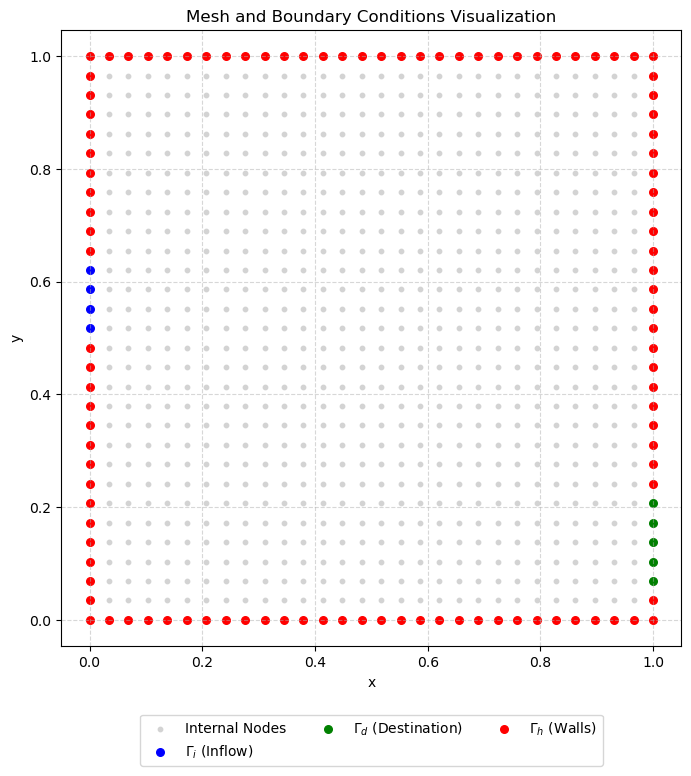

In [2]:
import matplotlib.pyplot as plt

def define_boundaries(N, start_in, count_in, start_dest, count_dest):
    """
    Defines indices for the three types of boundary conditions.
    
    Parameters:
        N: Number of nodes in one direction.
        start_in, count_in: Start index and height (in nodes) for inflow (left).
        start_dest, count_dest: Start index and height (in nodes) for destination (right).
    """
    gamma_i = [] # Inflow
    gamma_d = [] # Destination
    gamma_h = [] # Hard boundaries
    
    # All boundary indices
    for i in range(N):
        for j in range(N):
            # Check if node is on the perimeter
            if i == 0 or i == N-1 or j == 0 or j == N-1:
                # Left edge: Potential Inflow
                if i == 0:
                    if start_in <= j < start_in + count_in:
                        gamma_i.append((i, j))
                    else:
                        gamma_h.append((i, j))
                # Right edge: Potential Destination
                elif i == N-1:
                    if start_dest <= j < start_dest + count_dest:
                        gamma_d.append((i, j))
                    else:
                        gamma_h.append((i, j))
                # Top and Bottom edges (excluding corners already handled)
                else:
                    gamma_h.append((i, j))
                    
    return gamma_i, gamma_d, gamma_h

def plot_mesh_with_boundaries(X, Y, gamma_i, gamma_d, gamma_h):
    """
    Visualizes the mesh and the boundary types.
    """
    plt.figure(figsize=(8, 8))
    
    # Plot all mesh points in light gray
    plt.scatter(X, Y, color='lightgray', s=10, label='Internal Nodes')
    
    # Helper to extract X and Y coordinates from index lists
    def get_coords(idx_list):
        px = [X[i, j] for i, j in idx_list]
        py = [Y[i, j] for i, j in idx_list]
        return px, py

    # Plot specific boundaries
    ix, iy = get_coords(gamma_i)
    dx, dy = get_coords(gamma_d)
    hx, hy = get_coords(gamma_h)
    
    plt.scatter(ix, iy, color='blue', s=30, label='$\Gamma_i$ (Inflow)')
    plt.scatter(dx, dy, color='green', s=30, label='$\Gamma_d$ (Destination)')
    plt.scatter(hx, hy, color='red', s=30, label='$\Gamma_h$ (Walls)')
    
    plt.title("Mesh and Boundary Conditions Visualization")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=3)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.axis('equal')
    plt.show()

# Example usage:
N = 30
x, y, X, Y, h = define_mesh(N)
g_i, g_d, g_h = define_boundaries(N, start_in=15, count_in=4, start_dest=2, count_dest=5)
plot_mesh_with_boundaries(X, Y, g_i, g_d, g_h)

In [3]:
def build_all_boundary_masks(N, gamma_i, gamma_d, gamma_h):
    inflow_mask = np.zeros((N, N), dtype=bool)
    dest_mask   = np.zeros((N, N), dtype=bool)
    wall_mask   = np.zeros((N, N), dtype=bool)

    for i, j in gamma_i:
        inflow_mask[i, j] = True
    for i, j in gamma_d:
        dest_mask[i, j] = True
    for i, j in gamma_h:
        wall_mask[i, j] = True

    return inflow_mask, dest_mask, wall_mask

## 3. Initialization

In [4]:
def initialize_density(X, Y, kind="gaussian"):
    """
    Defines the initial pedestrian density rho(x,y,0).
    """
    if kind == "gaussian":                             #density highest at the center, gradually decreases away from the center
        x0, y0 = 0.18, 0.48
        sigma_x, sigma_y = 0.07, 0.06

        rho = 0.6 * np.exp(
            -((X - x0)**2 / (2 * sigma_x**2)
              + (Y - y0)**2 / (2 * sigma_y**2))
        )

    elif kind == "block":                            #sharp jump between desnity, people in a precise rectangular block
        rho = np.zeros_like(X)
        rho[5:15, 20:28] = 0.6

    elif kind == "empty":
        rho = np.zeros_like(X)

    else:
        raise ValueError("Unknown initial density type.")

    return rho

## 4. Functions of the problem 

### 4.1 Average Velocity-Density relationship

The relationship between the average walking velocity $u$ and the local density $\rho$ is a cornerstone of the Hughes model. These functions dictate how pedestrians slow down as the crowd becomes denser.

In this implementation, we consider three classical models adapted for dimensionless variables ($u_{max} = 1, \rho_{max} = 1$).

#### 4.1.1 Linear Model (Greenshields)
This is the simplest model, where velocity decreases linearly until it reaches the jam density $\rho_{max}$. It is highly efficient for numerical validation and capturing sharp shock waves.
$$u(\rho) = u_{max} \left( 1 - \frac{\rho}{\rho_{max}} \right)$$

### 2. Exponential Model (Underwood)
This model represents a more gradual decay of speed. It is often preferred in the Hughes model because it prevents the velocity from reaching absolute zero too abruptly, which can improve numerical stability.
$$u(\rho) = u_{max} \exp\left[ -\alpha \left( \frac{\rho}{\rho_{max}} \right)^2 \right]$$
* **$\alpha$**: A sensitivity parameter that controls how fast the speed drops as density increases.

### 3. Weidmann’s Model
Often used in German engineering standards, this model is based on empirical data from pedestrian observations. It describes a sharper decline in speed at low densities followed by a slower decay at high densities.
$$u(\rho) = u_{max} \left( 1 - \exp\left[ -\frac{1}{\gamma} \left( \frac{\rho_{max}}{\rho} - 1 \right) \right] \right)$$
* **$\gamma$**: A shape parameter (typically around $1.913$).

---

> **Implementation Note:** In all models, a small safety threshold $\epsilon = 10^{-3}$ is added to the velocity. This ensures that the cost function $c(\rho) = 1/u(\rho)$ remains finite, preventing division-by-zero errors during the Eikonal equation solving step.

## 4. Main Computational Loop (Time Integration)

### 4.1 The Local Cost Function $c(x, y, t)$

The cost function $c$ represents the "effort" or "time" required to travel a unit of distance. In the Hughes model, it is the fundamental link between the current density ($\rho$) and the navigation strategy ($\phi$). It is defined as the reciprocal of the **potential speed** perceived by pedestrians.

We consider two main formulations for $c(\rho)$:

### Option A: The Velocity-Only Model (Simplified)
In the simplest form, as often used for numerical validation in **Huang et al. (2009)**, the cost depends only on the local walking speed $u(\rho)$:
$$c(\rho) = \frac{1}{u(\rho)} = \frac{1}{u_{max}(1 - \rho/\rho_{max})}$$
* **Behavior**: Pedestrians strictly minimize their travel time. 
* **Limitation**: The cost approaches infinity as $\rho \to \rho_{max}$, which requires numerical regularization.
* 
#### Numerical Regularization
To ensure the stability of the Eikonal solver (Fast Sweeping Method), we implement a safety threshold $u_{min}$ to prevent division by zero:
$$c(\rho) = \frac{1}{\max(u(\rho), u_{min})}$$

### Option B: The Hughes Model with Discomfort
To model more realistic behaviors where pedestrians avoid crowded areas proactively, an **incomfort function** $g(\rho)$ is introduced:
$$c(\rho) = \frac{1}{u(\rho) \cdot g(\rho)}$$
A common choice for the comfort potential is $g(\rho) = \exp(-\alpha \rho^2)$, leading to:
$$c(\rho) = \frac{e^{\alpha \rho^2}}{u_{max}(1 - \rho/\rho_{max})}$$
* **Behavior**: The cost increases exponentially with density. Pedestrians will prefer a longer path in a clear area over a shorter path through a dense crowd.

### Non-dimensionalization
For the numerical implementation, we adopt **dimensionless variables** as is standard in the literature (Huang et al., 2009). We set the maximum density $\rho_{max} = 1$ and the free-flow speed $u_{max} = 1$. Consequently, the local density $\rho$ represents the occupancy ratio ($\rho \in [0, 1]$), and the velocity $u(\rho)$ is a fraction of the maximum walking speed. This approach generalizes the results and ensures better numerical stability for the WENO scheme.

In [5]:
def compute_speed(rho, rho_max=1.0, u_max=1.0, eps=1e-8):
    """
    Isotropic speed law u(rho).
    Simple dimensionless linear choice:
        u(rho) = u_max * (1 - rho/rho_max)
    clipped below by eps to avoid division issues later.
    """
    u = u_max * (1.0 - rho / rho_max)
    return np.maximum(u, eps)


def compute_flux_magnitude(rho, rho_max=1.0, u_max=1.0):
    """
    Section 4.3: compute ||f|| from formula (25):
        ||f|| = rho * u(rho)
    """
    u = compute_speed(rho, rho_max=rho_max, u_max=u_max)
    f_norm = rho * u
    return f_norm

def compute_cost(rho, alpha=0.5, mode="huang"):
    """
    Computes the local cost c(rho).
    """
    u = compute_speed(rho)
    u_safe = np.maximum(u, 0.05)

    mode = mode.lower()

    if mode == "simple":
        return 1.0 / u_safe

    elif mode == "hughes":
        g_inv = np.exp(alpha * rho**2)
        return g_inv / u_safe

    elif mode == "huang":                              #more stable than hughes
        g = 0.002 * rho**2
        return 1.0 / u_safe + g

    else:
        raise ValueError("Unknown cost mode.")

# Note: In the paper, Equation (12) often refers to this combined effect.

Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204


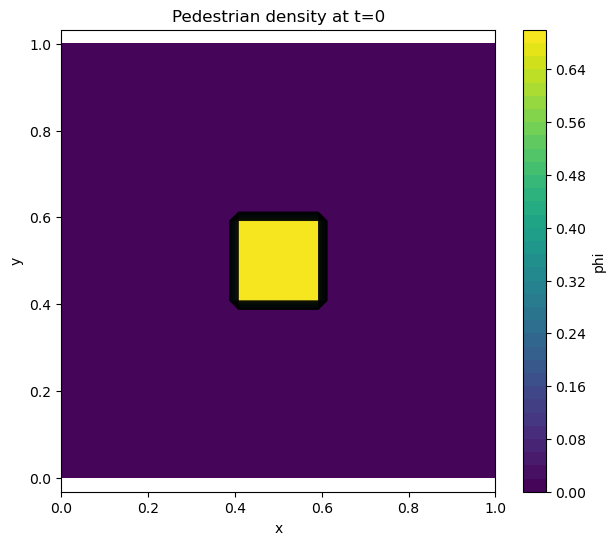

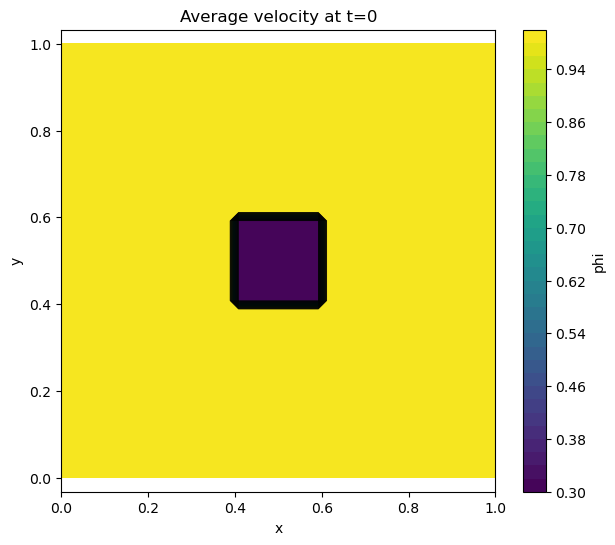

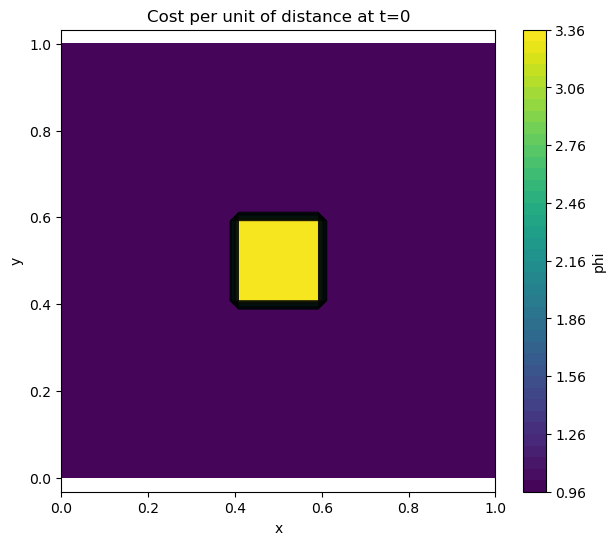

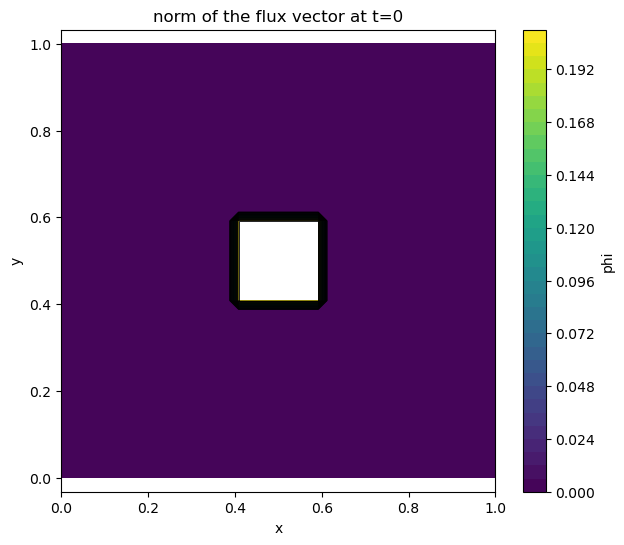

In [6]:
N = 50
x, y, X, Y, h = define_mesh(N)
gamma_i, gamma_d, gamma_h = define_boundaries(
    N,
    start_in=20, count_in=8,
    start_dest=20, count_dest=8
)

rho = np.zeros((N, N))
rho[20:30, 20:30] = 0.7

u = compute_speed(rho)
c = compute_cost(rho, mode='simple')
c_hughes = compute_cost(rho, mode='hughes')
c_Huang = compute_cost(rho, mode='Huang')
f_norm = compute_flux_magnitude(rho)

plt.figure(figsize=(7, 6))
plt.contour(X, Y, rho, levels=20, colors="black", linewidths=0.6)
plt.contourf(X, Y, rho, levels=40, cmap="viridis")
plt.colorbar(label="phi")
plt.title("Pedestrian density at t=0")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

plt.figure(figsize=(7, 6))
plt.contour(X, Y, u, levels=20, colors="black", linewidths=0.6)
plt.contourf(X, Y, u, levels=40, cmap="viridis")
plt.colorbar(label="phi")
plt.title("Average velocity at t=0")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

plt.figure(figsize=(7, 6))
plt.contour(X, Y, c_Huang, levels=20, colors="black", linewidths=0.6)
plt.contourf(X, Y, c_Huang, levels=40, cmap="viridis")
plt.colorbar(label="phi")
plt.title("Cost per unit of distance at t=0")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

plt.figure(figsize=(7, 6))
plt.contour(X, Y, f_norm, levels=20, colors="black", linewidths=0.6)
plt.contourf(X, Y, f_norm, levels=40, cmap="viridis")
plt.colorbar(label="phi")
plt.title("norm of the flux vector at t=0")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

### 4.2 Eikonal Equation for Potential $\phi$
Based on **Formula (15)**, we solve for the potential field using the **Fast Sweeping Method**:
$$\|\nabla \phi\| = c, \quad \phi|_{\Gamma_d} = 0$$

In [7]:
def solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, N, h, max_iter=500, tol=1e-10):
    """
    First-order Godunov fast sweeping solver for |grad phi| = c.
    This is the natural sanity check before using the WENO version.
    """
    phi = np.full((N, N), 1e6, dtype=float)

    dest_mask, wall_mask = build_masks_from_boundary_sets(N, gamma_d, gamma_h)
    phi[dest_mask] = 0.0
    phi[wall_mask] = 1e12


    sweep_orders = [
        (range(N), range(N)),
        (range(N - 1, -1, -1), range(N)),
        (range(N - 1, -1, -1), range(N - 1, -1, -1)),
        (range(N), range(N - 1, -1, -1)),
    ]

    for it in range(max_iter):
        phi_old = phi.copy()

        for i_range, j_range in sweep_orders:
            for i in i_range:
                for j in j_range:
                    if dest_mask[i, j] or wall_mask[i, j]:
                        continue

                    new_val=first_order_local_update(phi,c,i,j,h)
                    phi[i, j] = min(phi[i, j], new_val)

        err = np.max(np.abs(phi - phi_old))
        if err < tol:
            print(f"First-order fast sweeping converged in {it+1} iterations with error {err:.2e}")
            break

    return phi

def build_masks_from_boundary_sets(N, gamma_d, gamma_h):
    dest_mask = np.zeros((N, N), dtype=bool)
    wall_mask = np.zeros((N, N), dtype=bool)

    for i, j in gamma_d:
        dest_mask[i, j] = True
    for i, j in gamma_h:
        wall_mask[i, j] = True

    return dest_mask, wall_mask

def compute_fixed_band_mask(N, gamma_d, h, band_width_factor=2.0):
    """
    Paper: keep points with distance <= 2h from destination fixed.
    We approximate this directly on the grid.
    """
    fixed_mask = np.zeros((N, N), dtype=bool)
    dest_points = np.array(list(gamma_d), dtype=float)

    if len(dest_points) == 0:
        return fixed_mask

    for i in range(N):
        for j in range(N):
            d2 = np.min((dest_points[:, 0] - i) ** 2 + (dest_points[:, 1] - j) ** 2)
            dist = np.sqrt(d2) * h
            if dist <= band_width_factor * h:
                fixed_mask[i, j] = True

    return fixed_mask

# Third-order WENO derivatives (formulas 41-44 + y-analogues)

def weno_derivatives_3rd(phi, i, j, h, eps=1e-6):
    # x-direction
    center_x = (phi[i + 1, j] - phi[i - 1, j]) / (2.0 * h)
    backward_x = (3.0 * phi[i, j] - 4.0 * phi[i - 1, j] + phi[i - 2, j]) / (2.0 * h)
    forward_x  = (-3.0 * phi[i, j] + 4.0 * phi[i + 1, j] - phi[i + 2, j]) / (2.0 * h)

    r_minus = (
        eps + (phi[i, j] - 2.0 * phi[i - 1, j] + phi[i - 2, j]) ** 2
    ) / (
        eps + (phi[i + 1, j] - 2.0 * phi[i, j] + phi[i - 1, j]) ** 2
    )

    r_plus = (
        eps + (phi[i, j] - 2.0 * phi[i + 1, j] + phi[i + 2, j]) ** 2
    ) / (
        eps + (phi[i + 1, j] - 2.0 * phi[i, j] + phi[i - 1, j]) ** 2
    )

    w_minus = 1.0 / (1.0 + 2.0 * r_minus**2)
    w_plus  = 1.0 / (1.0 + 2.0 * r_plus**2)

    phi_x_minus = (1.0 - w_minus) * center_x + w_minus * backward_x
    phi_x_plus  = (1.0 - w_plus)  * center_x + w_plus  * forward_x

    # y-direction
    center_y = (phi[i, j + 1] - phi[i, j - 1]) / (2.0 * h)
    backward_y = (3.0 * phi[i, j] - 4.0 * phi[i, j - 1] + phi[i, j - 2]) / (2.0 * h)
    forward_y  = (-3.0 * phi[i, j] + 4.0 * phi[i, j + 1] - phi[i, j + 2]) / (2.0 * h)

    r_minus_y = (
        eps + (phi[i, j] - 2.0 * phi[i, j - 1] + phi[i, j - 2]) ** 2
    ) / (
        eps + (phi[i, j + 1] - 2.0 * phi[i, j] + phi[i, j - 1]) ** 2
    )

    r_plus_y = (
        eps + (phi[i, j] - 2.0 * phi[i, j + 1] + phi[i, j + 2]) ** 2
    ) / (
        eps + (phi[i, j + 1] - 2.0 * phi[i, j] + phi[i, j - 1]) ** 2
    )

    w_minus_y = 1.0 / (1.0 + 2.0 * r_minus_y**2)
    w_plus_y  = 1.0 / (1.0 + 2.0 * r_plus_y**2)

    phi_y_minus = (1.0 - w_minus_y) * center_y + w_minus_y * backward_y
    phi_y_plus  = (1.0 - w_plus_y)  * center_y + w_plus_y  * forward_y

    return phi_x_minus, phi_x_plus, phi_y_minus, phi_y_plus


def first_order_local_update(phi, c, i, j, h):
    N = phi.shape[0]

    left  = phi[i - 1, j] if i > 0     else phi[i, j]
    right = phi[i + 1, j] if i < N - 1 else phi[i, j]
    down  = phi[i, j - 1] if j > 0     else phi[i, j]
    up    = phi[i, j + 1] if j < N - 1 else phi[i, j]

    ax = min(left, right)
    ay = min(down, up)

    if abs(ax - ay) >= c[i, j] * h:
        return min(ax, ay) + c[i, j] * h
    else:
        disc = 2.0 * (c[i, j] * h) ** 2 - (ax - ay) ** 2
        disc = max(disc, 0.0)
        return 0.5 * (ax + ay + np.sqrt(disc))
        

def stencil_safe(i, j, N, wall_mask):
    if i < 2 or i > N - 3 or j < 2 or j > N - 3:
        return False
    if np.any(wall_mask[i - 2:i + 3, j - 2:j + 3]):
        return False
    return True


# WENO local update: formulas (39)-(40)

def local_phi_update_weno(phi_old, c, i, j, h, dest_mask, wall_mask):
    if dest_mask[i, j] or wall_mask[i, j]:
        return phi_old[i, j]

    N = phi_old.shape[0]

    # first-order fallback near boundaries / walls
    if not stencil_safe(i, j, N, wall_mask):
        return first_order_local_update(phi_old, c, i, j, h)

    phi_x_minus, phi_x_plus, phi_y_minus, phi_y_plus = weno_derivatives_3rd(phi_old, i, j, h)

    phi_x_min = min(phi_old[i, j] - h * phi_x_minus,
                    phi_old[i, j] + h * phi_x_plus)

    phi_y_min = min(phi_old[i, j] - h * phi_y_minus,
                    phi_old[i, j] + h * phi_y_plus)

    if abs(phi_x_min - phi_y_min) <= c[i, j] * h:
        phi_new = min(phi_x_min, phi_y_min) + c[i, j] * h
    else:
        disc = 2.0 * (c[i, j] * h) ** 2 - (phi_x_min - phi_y_min) ** 2
        disc = max(disc, 0.0)
        phi_new = 0.5 * (phi_x_min + phi_y_min + np.sqrt(disc))

    # potential should stay nonnegative
    return max(phi_new, 0.0)


def solve_phi_fast_sweeping_weno(
    c, gamma_d, gamma_h, N, h,
    max_iter=200,
    tol=1e-9
):
    """
    Third-order WENO fast sweeping solver for the Eikonal equation.

    Important:
    - The destination satisfies phi = 0.
    - External room walls are NOT assigned phi = 1e12.
    - Hard-wall/no-flux behaviour is imposed later in the density equation,
      not by making the potential infinite at the boundary.

    gamma_h is kept in the argument list for consistency, but is not used
    as an infinite-potential wall mask for the empty-room case.
    """

    # Destination mask only
    dest_mask = np.zeros((N, N), dtype=bool)
    for i, j in gamma_d:
        dest_mask[i, j] = True

    # For the empty-room case, do not treat external walls as obstacles
    wall_mask = np.zeros((N, N), dtype=bool)

    # First-order solution used as initial guess
    # Again: use [] instead of gamma_h, because external walls are not obstacles.
    phi = solve_phi_fast_sweeping_first_order(
        c, gamma_d, [], N, h,
        max_iter=500,
        tol=1e-10
    )

    # Enforce destination value
    phi[dest_mask] = 0.0

    # Freeze a small band around the destination
    fixed_mask = compute_fixed_band_mask(
        N, gamma_d, h,
        band_width_factor=2.0
    )
    fixed_mask = np.logical_or(fixed_mask, dest_mask)

    # Store fixed values once
    phi_fixed = phi.copy()

    sweep_orders = [
        (range(N), range(N)),
        (range(N - 1, -1, -1), range(N)),
        (range(N - 1, -1, -1), range(N - 1, -1, -1)),
        (range(N), range(N - 1, -1, -1)),
    ]

    for it in range(max_iter):
        phi_prev = phi.copy()

        for i_range, j_range in sweep_orders:
            for i in i_range:
                for j in j_range:

                    # Do not update destination/fixed points
                    if fixed_mask[i, j]:
                        continue

                    candidate = local_phi_update_weno(
                        phi_prev,
                        c,
                        i,
                        j,
                        h,
                        dest_mask,
                        wall_mask
                    )

                    # Monotone update
                    phi[i, j] = min(phi[i, j], candidate)

        # Re-enforce exact destination and frozen band
        phi[dest_mask] = 0.0
        phi[fixed_mask] = phi_fixed[fixed_mask]

        err = np.max(np.abs(phi - phi_prev))

        if err < tol:
            print(
                f"Fast sweeping WENO converged in {it + 1} iterations "
                f"with error {err:.2e}"
            )
            break

    else:
        print(
            f"Fast sweeping WENO reached max_iter={max_iter} "
            f"with error {err:.2e}"
        )

    return phi

In [8]:
N = 50
x, y, X, Y, h = define_mesh(N)
gamma_i, gamma_d, gamma_h = define_boundaries(
    N,
    start_in=20, count_in=8,
    start_dest=20, count_dest=8
)

rho = np.zeros((N, N))
rho[20:30, 20:30] = 0.7

u = compute_speed(rho)
c = compute_cost(rho, u, mode='simple')

phi_weno = solve_phi_fast_sweeping_weno(c, gamma_d, gamma_h, N, h)

Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204
First-order fast sweeping converged in 3 iterations with error 0.00e+00
Fast sweeping WENO converged in 52 iterations with error 8.90e-10


Interior phi min: 0.0
Interior phi max: 1.1141762941040239


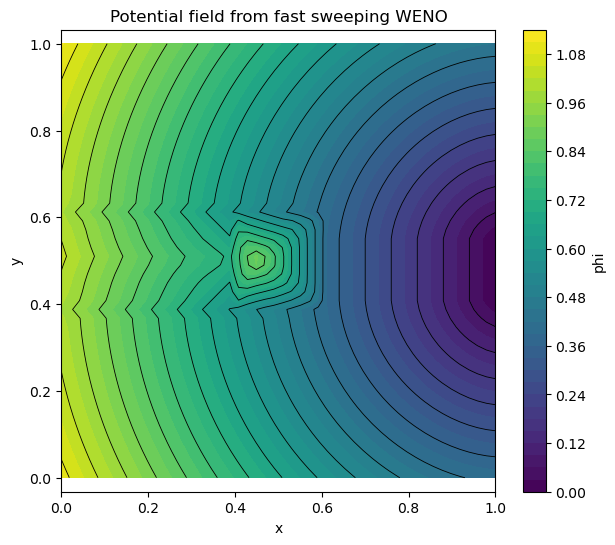

In [9]:
phi_plot = phi_weno.copy()
phi_plot[phi_plot > 1e11] = np.nan

interior = phi_weno[phi_weno < 1e11]
print("Interior phi min:", interior.min())
print("Interior phi max:", interior.max())

plt.figure(figsize=(7, 6))
plt.contour(X, Y, phi_plot, levels=20, colors="black", linewidths=0.6)
plt.contourf(X, Y, phi_plot, levels=40, cmap="viridis")
plt.colorbar(label="phi")
plt.title("Potential field from fast sweeping WENO")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

In [10]:
N = 50
x, y, X, Y, h = define_mesh(N)
gamma_i, gamma_d, gamma_h = define_boundaries(
    N,
    start_in=20, count_in=8,
    start_dest=20, count_dest=8
)

rho = np.zeros((N, N))
for i in range(N):
    rho[i, :] = 0.6 * (i / (N - 1))

c = compute_cost(rho, u, mode="simple")

phi_weno = solve_phi_fast_sweeping_weno(c, gamma_d, gamma_h, N, h)

Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204
First-order fast sweeping converged in 3 iterations with error 0.00e+00
Fast sweeping WENO converged in 21 iterations with error 5.88e-10


Interior phi min: 0.0
Interior phi max: 1.676148166500789


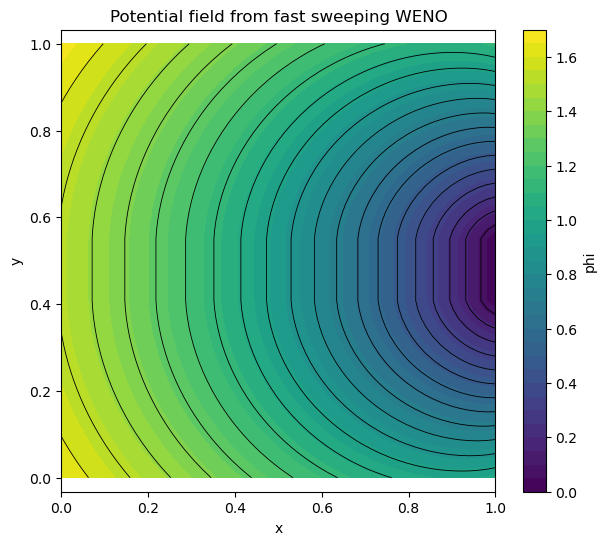

In [11]:
phi_plot = phi_weno.copy()
phi_plot[phi_plot > 1e11] = np.nan

interior = phi_weno[phi_weno < 1e11]
print("Interior phi min:", interior.min())
print("Interior phi max:", interior.max())

plt.figure(figsize=(7, 6))
plt.contour(X, Y, phi_plot, levels=20, colors="black", linewidths=0.6)
plt.contourf(X, Y, phi_plot, levels=40, cmap="viridis")
plt.colorbar(label="phi")
plt.title("Potential field from fast sweeping WENO")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

### 4.3 Flux Magnitude $\|\mathbf{f}\|$
Based on **Formula (25)**, we compute the magnitude of the pedestrian flow:
$$\|\mathbf{f}\| = \rho \cdot u(\rho)$$

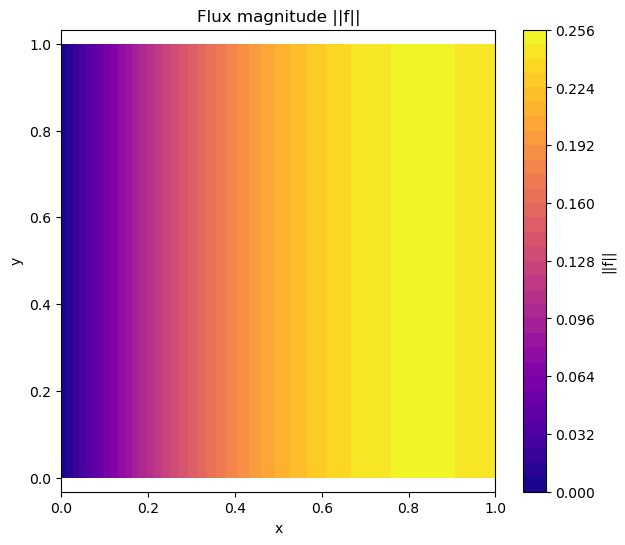

In [12]:
f_norm = compute_flux_magnitude(rho)

plt.figure(figsize=(7, 6))
plt.contourf(X, Y, f_norm, levels=40, cmap="plasma")
plt.colorbar(label="||f||")
plt.title("Flux magnitude ||f||")
plt.xlabel("x")
plt.ylabel("y")
plt.axis("equal")
plt.show()

### 4.4 Flux Vector $\mathbf{f}$
Based on **Formula (26)**, we determine the flow direction (downward gradient of $\phi$):
$$\mathbf{f} = \|\mathbf{f}\| \mathbf{n} = \|\mathbf{f}\| \left( -\frac{\nabla \phi}{\|\nabla \phi\|} \right)$$

#### The Godunov Selection Rule

In the Hughes model, pedestrians move to minimize their potential $\phi$ to reach the destination as efficiently as possible. This behavior is governed by the Eikonal equation $\|\nabla \phi\| = c$. 

The **Godunov selection rule** is essential for two primary reasons:

1. **Upwinding (Directional Causality)**: It ensures that the gradient is calculated based on information flowing from the destination. Since pedestrians move toward lower potential values, the numerical scheme must "look" in the direction of descending values to correctly estimate the path.
2. **Singularity Handling**: Potential fields often contain "kinks" or singularities where optimal paths from different directions meet (e.g., behind obstacles). The Godunov rule provides a unique, stable gradient selection in these regions, preventing numerical oscillations.

##### Mathematical Formulation
Given the left-sided WENO approximation $(\phi_x^-)$ and the right-sided approximation $(\phi_x^+)$, the final gradient component $\phi_x$ is determined by:
$$\phi_{x,ij} = \max(\phi_{x,ij}^-, 0) + \min(\phi_{x,ij}^+, 0)$$

* If $\phi_x^- > 0$, the potential increases to the right, implying the descent (and the destination) is to the **left**.
* If $\phi_x^+ < 0$, the potential decreases to the right, implying the descent is to the **right**.
* If both directions lead away from the point (a local minimum/maximum), the rule selects the correct physical characteristic to maintain stability.

This rule ensures that the flux vector $\mathbf{f}$ always points toward the steepest descent, guiding the crowd toward the target in a mathematically robust way.

In [56]:
import numpy as np

def compute_godunov_gradient(phi, h, gamma_h, eps_weno=1e-6):
    """
    Computes the gradient using WENO3 and accounts for walls using the provided list of tuples.
    """
    N = phi.shape[0]
    grad_x = np.zeros_like(phi)
    grad_y = np.zeros_like(phi)
    
    # Convert list to set for faster lookup (O(1) average time complexity)
    wall_set = set(gamma_h)
    
    for i in range(2, N - 2):
        for j in range(2, N - 2):
            # Skip computation for cells located inside a wall
            if (i, j) in wall_set:
                continue
            
            # Compute third-order WENO derivatives
            px_m, px_p, py_m, py_p = weno_derivatives_3rd(phi, i, j, h, eps_weno)
            
            # Godunov numerical flux to select the correct upwind direction
            grad_x[i, j] = np.maximum(px_m, 0) + np.minimum(px_p, 0)
            grad_y[i, j] = np.maximum(py_m, 0) + np.minimum(py_p, 0)
            
    return grad_x, grad_y

def compute_unit_direction(grad_x, grad_y, epsilon=1e-8):
    """
    Computes the unit direction vector n = -grad(phi) / |grad(phi)|
    """
    norm = np.sqrt(grad_x**2 + grad_y**2 + epsilon)
    n1 = -grad_x / norm
    n2 = -grad_y / norm
    return n1, n2

#### Flux Vector Determination via Equation (26)

The flux vector $\mathbf{f}$ represents the movement of pedestrians across the domain. Following the mathematical formulation in **Equation (26)** of Huang et al. (2009):
$$c(\rho, x, y, t) \mathbf{f} + \|\mathbf{f}\| \nabla \phi = 0$$

By isolating $\mathbf{f}$, we obtain a direct relationship between the flux, the potential gradient, and the cost function:
$$\mathbf{f} = - \frac{\|\mathbf{f}\|}{c} \nabla \phi$$

In [37]:
import numpy as np
import matplotlib.pyplot as plt

def compute_flux_from_eq26(rho, u, cost, grad_x, grad_y):
    """
    Computes the flux vector f based on Equation (26) from Huang et al. (2009):
    f = -(||f|| / c) * grad(phi)
    where ||f|| = rho * u(rho)
    
    Parameters:
        rho    : Density grid (2D array)
        u      : Velocity grid u(rho) (2D array)
        cost   : Potential cost grid c(rho) (2D array)
        grad_x : X-component of potential gradient (Godunov)
        grad_y : Y-component of potential gradient (Godunov)
        
    Returns:
        f1, f2 : Components of the flux vector field
    """
    # Magnitude of the flux ||f|| according to the fundamental diagram
    f_norm = rho * u
    
    # According to Eq (26), f and grad(phi) are anti-parallel.
    # We normalize the gradient by the cost 'c' (since ||grad_phi|| = c)
    # and scale it by the flow magnitude ||f||.
    # Added 1e-8 to avoid division by zero at destinations.
    f1 = -(f_norm / (cost + 1e-8)) * grad_x
    f2 = -(f_norm / (cost + 1e-8)) * grad_y
    
    return f1, f2

def plot_pedestrian_flow(f1, f2, rho, step=3):
    """
    Visualizes the flux vector field f overlaid on the density map rho.
    
    Parameters:
        f1, f2 : Flux vector components
        rho    : Density grid for background visualization
        step   : Slicing interval for quiver arrows to ensure clarity
    """
    N = rho.shape[0]
    # Define grid coordinates for plotting
    x = np.linspace(0, 1, N)
    y = np.linspace(0, 1, N)
    X, Y = np.meshgrid(x, y)
    
    plt.figure(figsize=(10, 8))
    
    # Plot density field as a colored background
    contour = plt.contourf(X, Y, rho.T, cmap='YlOrRd', levels=20, alpha=0.8)
    plt.colorbar(contour, label='Density $\\rho$')
    
    # Plot flux vectors using quiver
    # Transpose is used on f and rho to match meshgrid (x,y) orientation
    plt.quiver(X[::step, ::step], Y[::step, ::step], 
               f1[::step, ::step].T, f2[::step, ::step].T, 
               color='black', scale=25, pivot='middle', width=0.002)
    
    plt.title("Pedestrian Flux Vector Field $\mathbf{f}$ (Based on Eq. 26)")
    plt.xlabel("x-coordinate")
    plt.ylabel("y-coordinate")
    plt.tight_layout()
    plt.show()

Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204
First-order fast sweeping converged in 3 iterations with error 0.00e+00
Fast sweeping WENO converged in 21 iterations with error 5.88e-10


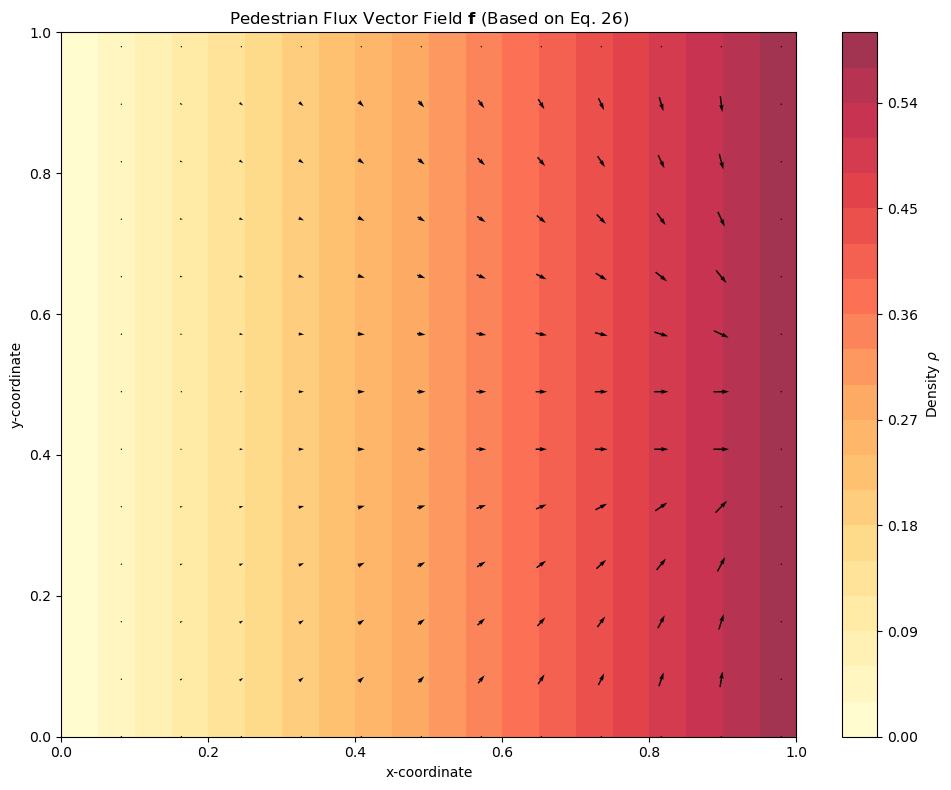

In [39]:
N = 50
x, y, X, Y, h = define_mesh(N)
gamma_i, gamma_d, gamma_h = define_boundaries(
    N,
    start_in=20, count_in=8,
    start_dest=20, count_dest=8
)

rho = np.zeros((N, N))
for i in range(N):
    rho[i, :] = 0.6 * (i / (N - 1))
#rho[20:30, 20:30] = 0.7

c = compute_cost(rho, u, mode="simple")

phi = solve_phi_fast_sweeping_weno(c, gamma_d, gamma_h, N, h)

# 1. Compute the potential gradient using the Godunov rule (Upwind)
# This uses the weno_derivatives_3rd function you provided earlier
grad_x, grad_y = compute_godunov_gradient(phi, h,gamma_h)

# 2. Compute the flux vector field f based on Equation (26)
# Formula: f = -(||f|| / c) * grad(phi) where ||f|| = rho * u
f1, f2 = compute_flux_from_eq26(rho, u, c, grad_x, grad_y)

# 3. Display the results
# The 'step' parameter skips points to make arrows readable on the grid
plot_pedestrian_flow(f1, f2, rho, step=4)

### 4.5 Conservation Law Update

Based on **Formula (24)**, we solve the transport equation using:
* **Lax–Friedrichs Flux Splitting** (Eq. 36)
* **5th-order WENO Reconstruction** (Eq. 31-35)
* **Euler Forward** or **TVD-RK3** time marching.

In [40]:
def first_order_local_update(phi, c, i, j, h):
    N = phi.shape[0]

    left  = phi[i - 1, j] if i > 0     else phi[i, j]
    right = phi[i + 1, j] if i < N - 1 else phi[i, j]
    down  = phi[i, j - 1] if j > 0     else phi[i, j]
    up    = phi[i, j + 1] if j < N - 1 else phi[i, j]

    ax = min(left, right)
    ay = min(down, up)

    if abs(ax - ay) >= c[i, j] * h:
        return min(ax, ay) + c[i, j] * h
    else:
        disc = 2.0 * (c[i, j] * h) ** 2 - (ax - ay) ** 2
        disc = max(disc, 0.0)
        return 0.5 * (ax + ay + np.sqrt(disc))

In [41]:
def plot_density_rate(d_rho_dt, title="Density Rate of Change (d_rho/dt)"):
    plt.figure(figsize=(8, 6))

    limit = np.max(np.abs(d_rho_dt))
    if limit == 0:
        limit = 1.0

    im = plt.imshow(
        d_rho_dt.T,          # IMPORTANT: transpose
        extent=[0, 1, 0, 1],
        origin="lower",
        cmap="RdBu_r",
        vmin=-limit,
        vmax=limit,
        aspect="equal"
    )

    plt.colorbar(im, label="Rate of Change")
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

In [42]:
def build_all_boundary_masks(N, gamma_i, gamma_d, gamma_h):
    inflow_mask = np.zeros((N, N), dtype=bool)
    dest_mask   = np.zeros((N, N), dtype=bool)
    wall_mask   = np.zeros((N, N), dtype=bool)

    for i, j in gamma_i:
        inflow_mask[i, j] = True

    for i, j in gamma_d:
        dest_mask[i, j] = True

    for i, j in gamma_h:
        wall_mask[i, j] = True

    return inflow_mask, dest_mask, wall_mask

In [60]:
def compute_drho_dt(rho, f1, f2, h, gamma_i, gamma_d, gamma_h, inflow_flux=0.0):
    """
    Computes d(rho)/dt = -div(f) using a first-order Upwind scheme for stability.
    
    The Upwind scheme selects the flux from the upstream cell based on the 
    flow direction, preventing numerical oscillations and artificial mass growth.
    """
    N = rho.shape[0]
    
    # Rebuild boundary masks from the provided lists
    inflow_mask, dest_mask, wall_mask = build_all_boundary_masks(N, gamma_i, gamma_d, gamma_h)

    # Initialize flux arrays at the interfaces
    # fx: Flux through vertical interfaces (size N+1 x N)
    # fy: Flux through horizontal interfaces (size N x N+1)
    fx = np.zeros((N + 1, N))
    fy = np.zeros((N, N + 1))

    # --- INTERNAL INTERFACES: UPWIND SELECTION ---
    
    # X-direction: Calculate flux fx[i, j] between cell i-1 and cell i
    for i in range(1, N):
        # Determine average local flow direction at the interface
        v_face_x = 0.5 * (f1[i-1, :] + f1[i, :]) 
        
        # Upwind logic: if flow is positive (left to right), take flux from the left cell.
        # Otherwise (right to left), take flux from the right cell.
        fx[i, :] = np.where(v_face_x >= 0, f1[i-1, :], f1[i, :])

    # Y-direction: Calculate flux fy[i, j] between cell j-1 and cell j
    for j in range(1, N):
        # Determine average local flow direction at the interface
        v_face_y = 0.5 * (f2[:, j-1] + f2[:, j])
        
        # Upwind logic: if flow is positive (bottom to top), take flux from the bottom cell.
        fy[:, j] = np.where(v_face_y >= 0, f2[:, j-1], f2[:, j])

    # --- BOUNDARY CONDITIONS ---

    # Left Boundary (i=0): Apply prescribed inflow flux where defined
    fx[0, inflow_mask[0, :]] = inflow_flux
    
    # Right Boundary (i=N): Allow outflow at destination points
    # We ensure only outgoing flux (positive) is accounted for at the exit
    fx[N, dest_mask[N-1, :]] = np.maximum(f1[N-1, dest_mask[N-1, :]], 0.0)

    # Walls and other boundaries (fx[0, :], fx[N, :], fy[:, 0], fy[:, N]) 
    # remain 0.0 as initialized by np.zeros (No-flux condition)

    # --- CONSERVATION LAW: rho_t = -div(f) ---
    # Standard finite volume discretization of the divergence operator
    div_f = (fx[1:, :] - fx[:-1, :]) / h + (fy[:, 1:] - fy[:, :-1]) / h

    return -div_f

Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204
First-order fast sweeping converged in 3 iterations with error 0.00e+00


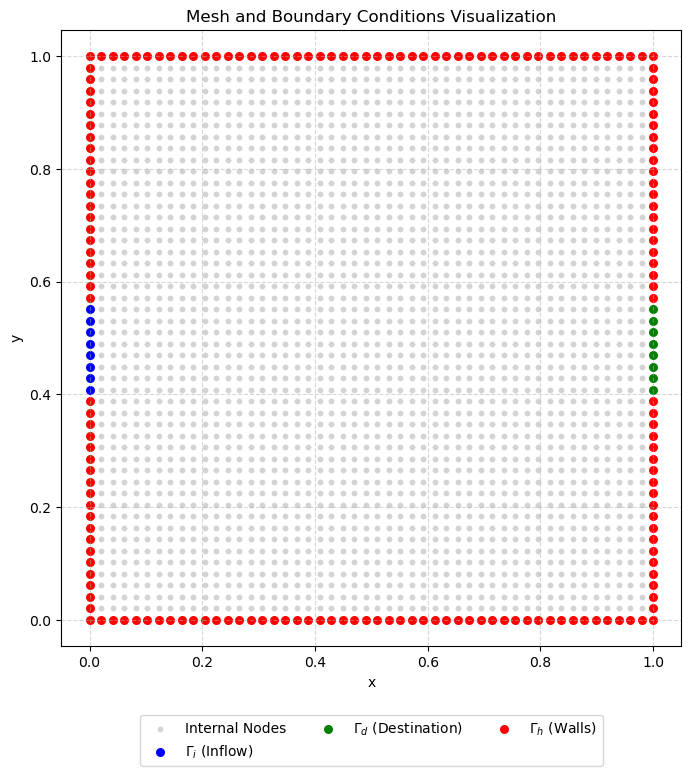

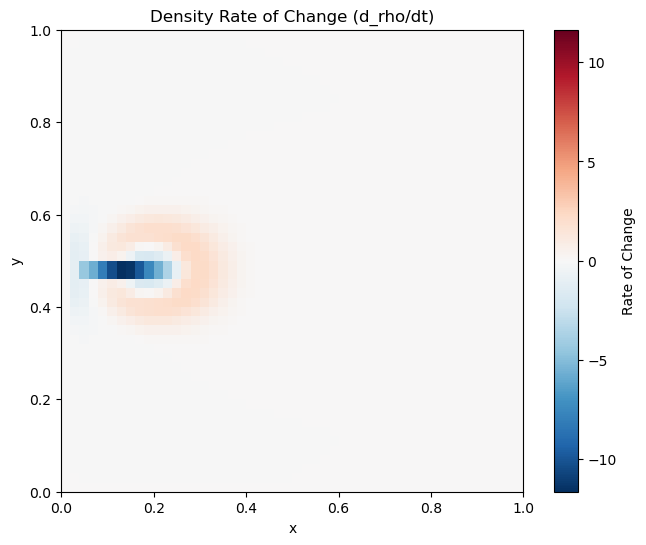

In [49]:
# ============================================================
# Final diagnostic setup
# ============================================================

# --- Case parameters: change only these values ---
N = 50

entrance_start = 20
entrance_count = 8

exit_start = 20
exit_count = 8

density_type = "gaussian"   # options: "gaussian", "block", "empty"
cost_mode = "huang"         # options: "simple", "hughes", "huang"

inflow_flux = 0.0           # no people enter after t = 0

# --- Mesh ---
x, y, X, Y, h = define_mesh(N)

# --- Boundaries ---
gamma_i, gamma_d, gamma_h = define_boundaries(
    N,
    start_in=entrance_start,
    count_in=entrance_count,
    start_dest=exit_start,
    count_dest=exit_count
)

# --- Initial density ---
rho = initialize_density(X, Y, kind=density_type)

# --- Speed and cost ---
u = compute_speed(rho)
c = compute_cost(rho, u, mode=cost_mode)

# --- Potential field ---
# Use [] instead of gamma_h because external room walls are handled
# through zero-flux conditions in the density equation, not as obstacles.
phi = solve_phi_fast_sweeping_first_order(
    c, gamma_d, gamma_h, N, h
)

# If you want to use the WENO potential solver instead, use:
# phi = solve_phi_fast_sweeping_weno(c, gamma_d, gamma_h, N, h)

# --- Gradient of potential ---
grad_x, grad_y = compute_godunov_gradient(phi, h, gamma_h)

# --- Hughes flux ---
f1, f2 = compute_flux_from_eq26(
    rho, u, c, grad_x, grad_y
)

# --- Density rate ---
d_rho_dt = compute_drho_dt(
    rho, f1, f2, h,
    gamma_i, gamma_d, gamma_h,
    inflow_flux=inflow_flux
)

# --- Plots ---
plot_mesh_with_boundaries(X, Y, gamma_i, gamma_d, gamma_h)
plot_density_rate(d_rho_dt)

Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204
First-order fast sweeping converged in 3 iterations with error 0.00e+00


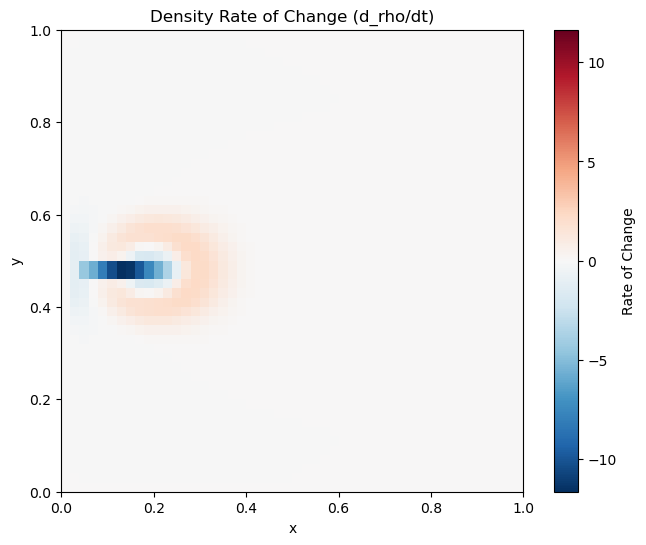

In [50]:
N = 50
x, y, X, Y, h = define_mesh(N)

gamma_i, gamma_d, gamma_h = define_boundaries(
    N,
    start_in=20, count_in=8,
    start_dest=20, count_dest=8
)

# Empty room first
rho = np.zeros((N, N))
x0, y0 = 0.18, 0.48
sigma_x, sigma_y = 0.07, 0.06

rho = 0.6 * np.exp(
    -((X - x0)**2 / (2 * sigma_x**2) + (Y - y0)**2 / (2 * sigma_y**2))
)

u = compute_speed(rho)
c = compute_cost(rho, u, mode="Huang")

phi = solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, N, h)

inflow_mask, dest_mask, wall_mask = build_all_boundary_masks(
    N, gamma_i, gamma_d, gamma_h
)

grad_x, grad_y = compute_godunov_gradient(phi, h,gamma_h)

f1, f2 = compute_flux_from_eq26(rho, u, c, grad_x, grad_y)

d_rho_dt = compute_drho_dt(
    rho, f1, f2, h,
    gamma_i, gamma_d, gamma_h,
    inflow_flux=0.0     # nobody enters after t = 0
)

plot_density_rate(d_rho_dt)

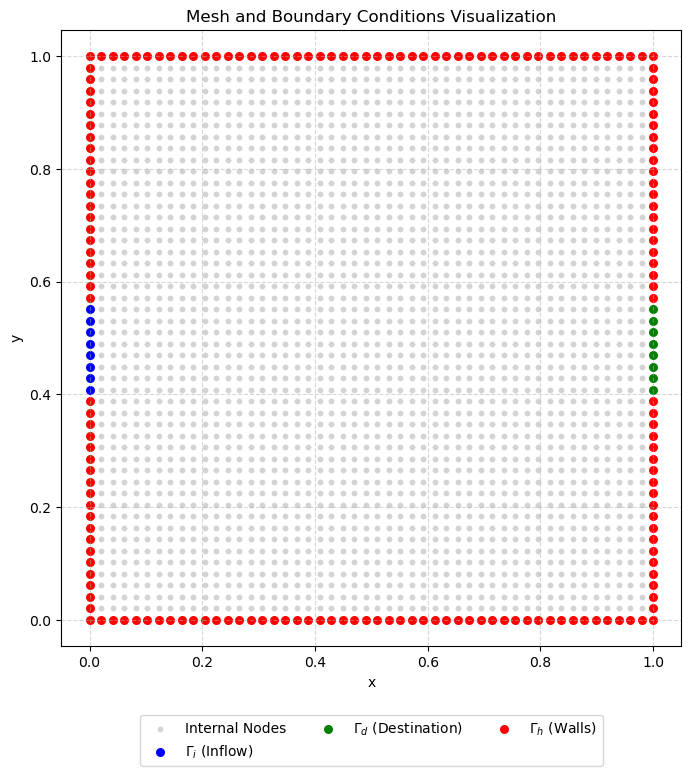

In [51]:
plot_mesh_with_boundaries(X, Y, gamma_i, gamma_d, gamma_h)

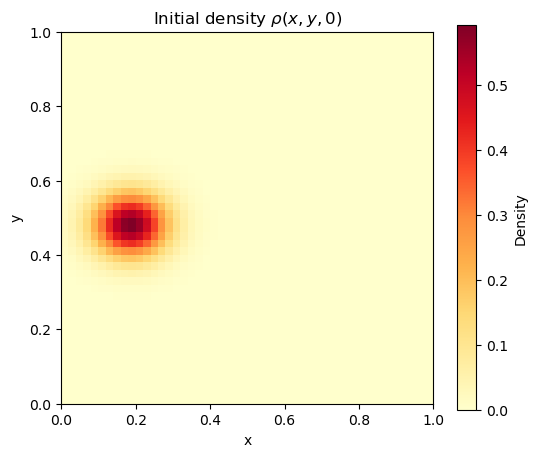

In [52]:
plt.figure(figsize=(6, 5))
plt.imshow(
    rho.T,
    extent=[0, 1, 0, 1],
    origin="lower",
    cmap="YlOrRd",
    aspect="equal"
)
plt.colorbar(label="Density")
plt.title("Initial density $\\rho(x,y,0)$")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

### Time Propagation using TVD Runge–Kutta time discretization

In [53]:
def compute_L(rho_curr, N, h, gamma_i, gamma_d, gamma_h, inflow_flux):
    """
    Spatial operator using exclusively lists for boundary conditions.
    """
    # Note: compute_cost only takes rho as an argument in your definition
    u = compute_speed(rho_curr) 
    c = compute_cost(rho_curr, mode="huang")
    
    # Eikonal solver: Passing [] instead of gamma_h so that walls 
    # are handled by the flux conditions rather than an infinite potential
    phi = solve_phi_fast_sweeping_first_order(c, gamma_d, gamma_h, N, h)
    
    # Gradient (receives gamma_h list to ignore walls)
    grad_x, grad_y = compute_godunov_gradient(phi, h, gamma_h)
    
    # Flux f = -(||f||/c) * grad(phi)
    f1, f2 = compute_flux_from_eq26(rho_curr, u, c, grad_x, grad_y)
    
    # Divergence (Mass balance)
    return compute_drho_dt(rho_curr, f1, f2, h, gamma_i, gamma_d, gamma_h, inflow_flux)
    
def step_RK3(rho_n, N, h, dt, gamma_i, gamma_d, gamma_h, inflow_flux):
    # Step 1
    L0 = compute_L(rho_n, N, h, gamma_i, gamma_d, gamma_h, inflow_flux)
    rho1 = rho_n + dt * L0
    
    # Step 2
    L1 = compute_L(rho1, N, h, gamma_i, gamma_d, gamma_h, inflow_flux)
    rho2 = 0.75 * rho_n + 0.25 * (rho1 + dt * L1)
    
    # Step 3
    L2 = compute_L(rho2, N, h, gamma_i, gamma_d, gamma_h, inflow_flux)
    rho_new = (1/3) * rho_n + (2/3) * (rho2 + dt * L2)
    
    return np.maximum(rho_new, 0.0)

def run_simulation(rho_initial, T_final, N, h, gamma_i, gamma_d, gamma_h, inflow_flux, n_snapshots=5):
    rho = rho_initial.copy()
    t = 0.0
    it = 0
    save_interval = T_final / (n_snapshots - 1) if n_snapshots > 1 else T_final
    next_save_t = 0.0
    history = []
    
    print(f"Starting simulation... Grid: {N}x{N}, T_final: {T_final}")
    
    while t < T_final:
        dt = 0.4 * h / 1.0  # Slightly more conservative CFL (0.4)
        
        if t + dt > T_final:
            dt = T_final - t
            
        if t >= next_save_t - 1e-9:
            history.append((t, rho.copy()))
            print(f" Snapshot saved at t = {t:.2f}")
            next_save_t += save_interval

        # RK3 Update
        rho = step_RK3(rho, N, h, dt, gamma_i, gamma_d, gamma_h, inflow_flux)
        
        t += dt
        it += 1
        
        if it % 5 == 0:
            mass = np.sum(rho) * (h**2)
            print(f"  Step {it:3d} | Time: {t:.3f} | Mass: {mass:.4f}")

    if len(history) < n_snapshots:
        history.append((t, rho.copy()))
        
    return history

In [58]:
# 1. Parameters
N = 50
T_final = 1.0
x, y, X, Y, h = define_mesh(N)

# 2. Generate boundary lists directly (No more get_boundary_masks)
# These are lists of (i, j) tuples
list_inflow, list_dest, list_walls = define_boundaries(
    N, 
    start_in=20, count_in=10, 
    start_dest=20, count_dest=10
)

# 3. Initial density
rho_init = initialize_density(X, Y, kind="gaussian")

# 4. Run simulation 
# We pass the lists directly. No conversion needed.
simulation_results = run_simulation(
    rho_init, T_final, N, h, 
    list_inflow, list_dest, list_walls, 
    inflow_flux=0.0, n_snapshots=5
)


Mesh generated with N = 50 nodes.
Uniform grid spacing h = 0.0204
Starting simulation... Grid: 50x50, T_final: 1.0
 Snapshot saved at t = 0.00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.00e+00
First-order fast sweeping converged in 3 iterations with error 0.

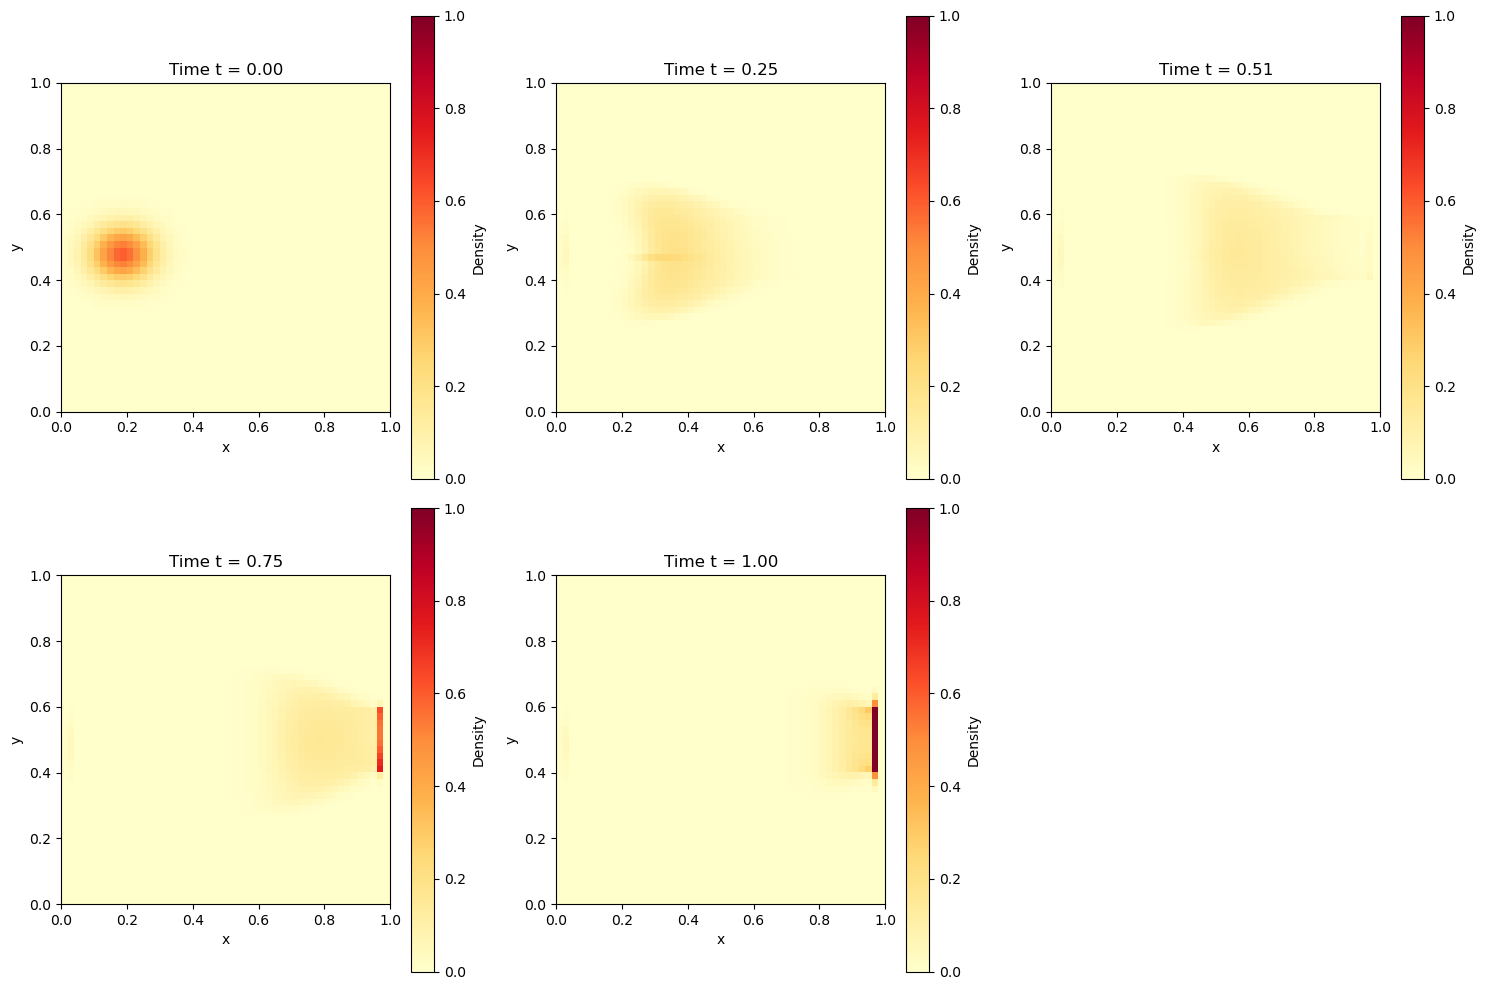

In [59]:
def plot_simulation_results(history, X, Y, n_cols=3):
    """
    Visualize density snapshots stored in the simulation history.
    """
    n_snapshots = len(history)
    n_rows = (n_snapshots + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()
    
    for i, (t, rho) in enumerate(history):
        ax = axes[i]
        # Use transpose .T to match the 'ij' indexing of the meshgrid
        im = ax.imshow(
            rho.T, 
            extent=[0, 1, 0, 1], 
            origin='lower', 
            cmap='YlOrRd', 
            vmin=0, vmax=1.0
        )
        ax.set_title(f"Time t = {t:.2f}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        fig.colorbar(im, ax=ax, label='Density')

    # Hide empty axes if necessary
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()

# --- Function Call ---
# Ensure that simulation_results is the list returned by run_simulation
plot_simulation_results(simulation_results, X, Y)